In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters
from skimage.io import imread
from skimage.feature import corner_peaks
from preprocessing import *
from solver import solve_sudoku, display_board, is_valid_sudoku

In [2]:
def display_image_grayscale(image, title="Image"):
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

def display_image_color(image, title="Image"):
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()

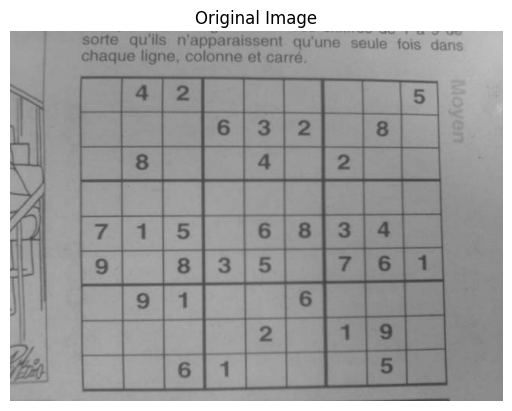

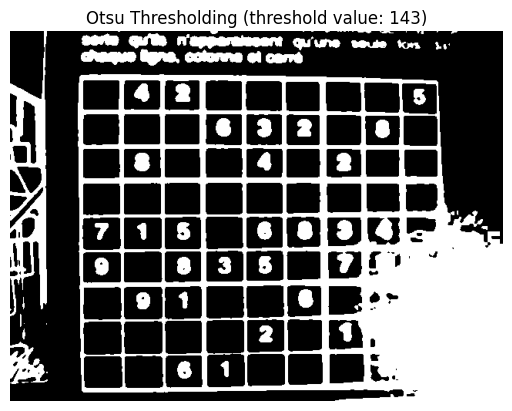

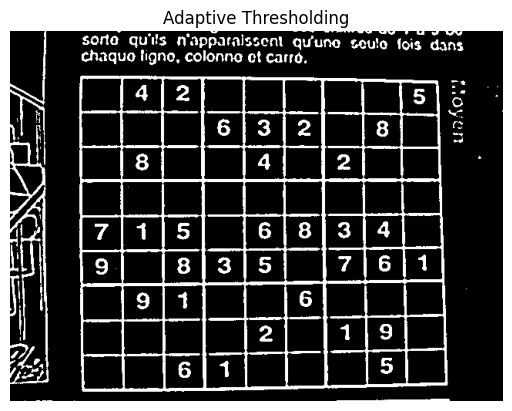

[ WARN:0@1.865] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


In [3]:
image_path = "report/images/original.jpg"

# Read the image in grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
display_image_grayscale(img, "Original Image")
if img is None:
    raise ValueError("Image not found. Check the path.")

original = img.copy()

# Pre-process: Blur and Adaptive Thresholding
# Gaussian blur reduces high-frequency noise
gaussian_kernel = create_gaussian_kernel(9, 1.6)
blurred = linear_filter(img, gaussian_kernel, is_clipped=True)

(hist, bin) = create_histogram(blurred, 256, is_normalized=False)
threshold_val = find_otsu_threshold(hist)
thresh_otsu = perform_global_threshold(blurred, threshold_val, is_inverse=True)
display_image_grayscale(thresh_otsu, f"Otsu Thresholding (threshold value: {threshold_val})")

# Thresholding
thresh_adaptive = apply_adaptive_threshold(blurred, 11, 2, is_inverse=True)
display_image_grayscale(thresh_adaptive, f"Adaptive Thresholding")

success = cv2.imwrite("report/images/otsu_thresholding.png", thresh_otsu)
success = cv2.imwrite("report/images/adaptive_thresholding.png", thresh_adaptive)

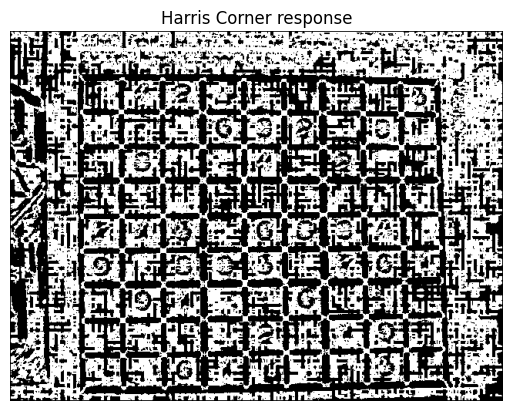

In [4]:
# Compute Harris corner response
corner_response = harris_corners(img)
display_image_grayscale(corner_response, "Harris Corner response")

Text(0.5, 1.0, 'Detected Corners')

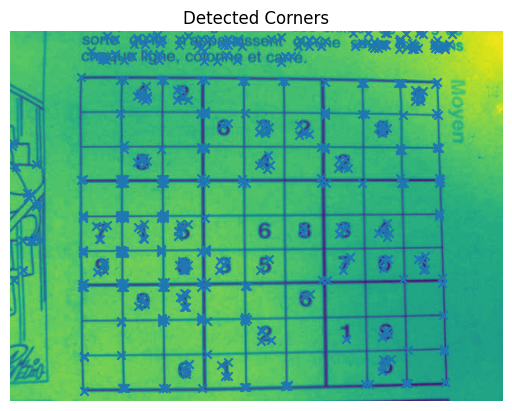

In [5]:
corners = corner_peaks(corner_response, threshold_rel=0.2)
# Display detected corners
plt.imshow(img)
plt.scatter(corners[:,1], corners[:,0], marker='x')
plt.axis('off')
plt.title('Detected Corners')

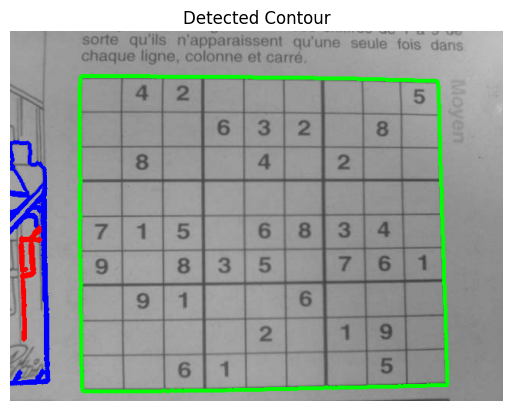

In [6]:
# Find contours (I don't think we can build custom version)
contours, _ = cv2.findContours(thresh_adaptive, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # Suzuki Abe algorithm

contours = sorted(contours, key=cv2.contourArea, reverse=True)

debug_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Example colors (BGR)
colors = [(0, 255, 0), (0, 0, 255), (255, 0, 0)]  

for i, cnt in enumerate([contours[0], contours[1], contours[2]]):
    color = colors[i % len(colors)]  # cycle colors if you have more contours
    cv2.drawContours(debug_img, [cnt], -1, color, 3)

display_image_grayscale(debug_img, "Detected Contour")
success = cv2.imwrite("report/images/contours.png", debug_img)

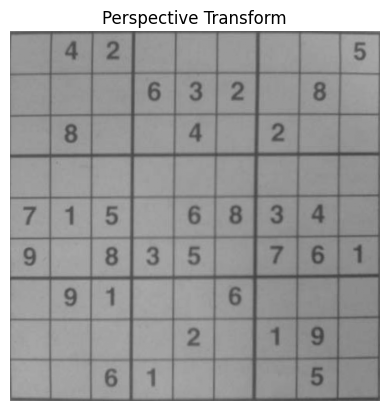

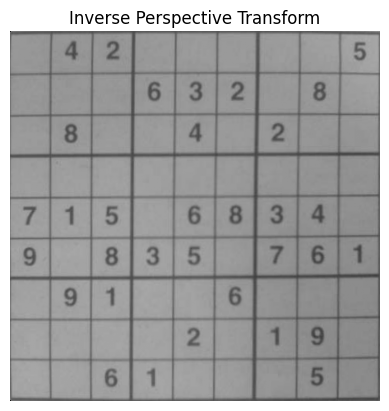

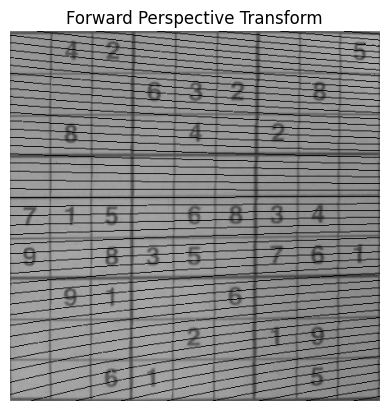

In [7]:
grid_contour = None
for contour in contours[:5]:
    contour = contour[:,0,:]
    perimeter = find_arc_length(contour, is_closed=True)
    epsilon = 0.02 * perimeter
    approx = approximate_polygon(contour, epsilon, is_closed=True)
    if len(approx) == 4:
        grid_contour = approx
        break


if grid_contour is None:
    raise ValueError("Could not find 4 corners of the Sudoku board. Try better lighting.")


# Perspective Transform (Flatten the board)
rect = order_points(grid_contour)

# Create a perfect square image to map the board to (450x450 is easily divisible by 9)
side_length = 450
dst = np.array([
    [0, 0],
    [side_length - 1, 0],
    [side_length - 1, side_length - 1],
    [0, side_length - 1]
], dtype="float32")

# Calculate the homography matrix and apply it
matrix = cv2.getPerspectiveTransform(rect, dst)

# added logic to pick and choose the warp function and which one to use overall
board_img = cv2.warpPerspective(original, matrix, (side_length, side_length))
board_img_custom_inverse = warp_perspective_inverse(original, matrix, (side_length, side_length))
board_img_custom_forward = warp_perspective_forward(original, matrix, (side_length, side_length))
display_image_grayscale(board_img, "Perspective Transform")
display_image_grayscale(board_img_custom_inverse, "Inverse Perspective Transform")
display_image_grayscale(board_img_custom_forward, "Forward Perspective Transform")


success = cv2.imwrite("report/images/inverse_warping.png", board_img_custom_inverse)
success = cv2.imwrite("report/images/forward_warping.png", board_img_custom_forward)

# select the warp transform to use for the rest of the pipeline
board_img = board_img_custom_inverse


Is top left cell empty: True


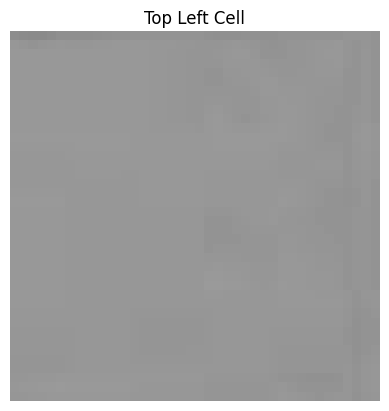

Is top right cell empty: False


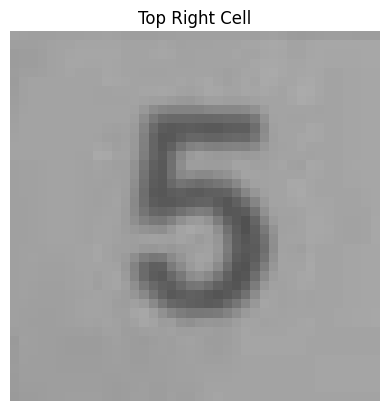

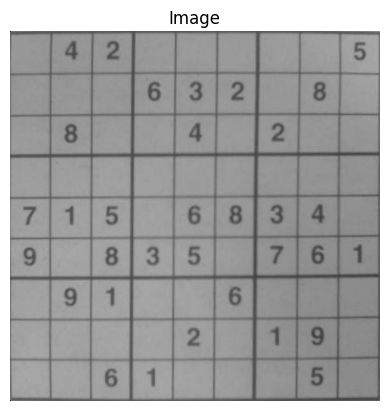

Unsolved board:
. 4 2 | . . . | . . 5 
. . . | 6 3 2 | . 8 . 
. 8 . | . 4 . | 2 . . 
------+-------+------
. . . | . . . | . . . 
7 1 5 | . 6 8 | 3 4 . 
9 . 8 | 3 5 . | 7 6 1 
------+-------+------
. 9 1 | . . 6 | . . . 
. . . | . 2 . | 1 9 . 
. . 6 | 1 . . | . 5 . 

Solved board:
3 4 2 | 8 9 1 | 6 7 5 
1 5 7 | 6 3 2 | 9 8 4 
6 8 9 | 7 4 5 | 2 1 3 
------+-------+------
4 6 3 | 9 1 7 | 5 2 8 
7 1 5 | 2 6 8 | 3 4 9 
9 2 8 | 3 5 4 | 7 6 1 
------+-------+------
5 9 1 | 4 7 6 | 8 3 2 
8 7 4 | 5 2 3 | 1 9 6 
2 3 6 | 1 8 9 | 4 5 7 


In [8]:
import joblib

from utils import normalize_cell, extract_features
model = joblib.load("models/digit_model.pkl")

def recognize_digits(cells):
    board = []
    for i in range(9):
        row = []
        for j in range(9):
            cell_img, is_empty = cells[i * 9 + j]
            if is_empty:
                row.append(".")
            else:
                cell_normalized = normalize_cell(cell_img)
                features = extract_features([cell_normalized])
                digit = model.predict(features)[0]
                row.append(str(digit))
        board.append(row)
    return board


final_cells = extract_sudoku_cells(board_img)
board = recognize_digits(final_cells)

if not is_valid_sudoku(board):
    raise ValueError("Invalid board — digit recognition may have errors or the board is impossible to solve.")

print(f"Is top left cell empty: {final_cells[0][1]}")
display_image_grayscale(final_cells[0][0], "Top Left Cell")
success = cv2.imwrite("report/images/top_left_cell.png", final_cells[0][0])


print(f"Is top right cell empty: {final_cells[8][1]}")
display_image_grayscale(final_cells[8][0], "Top Right Cell")
success = cv2.imwrite("report/images/top_right_cell.png", final_cells[8][0])

display_image_grayscale(board_img)
print("Unsolved board:")
display_board(board)
solve_sudoku(board)
print()
print("Solved board:")
display_board(board)

## Another Image (Largest contour is not the sudoku board)

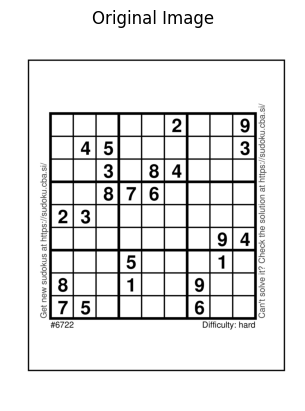

(2200, 1700)


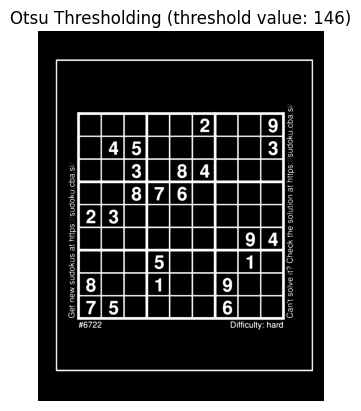

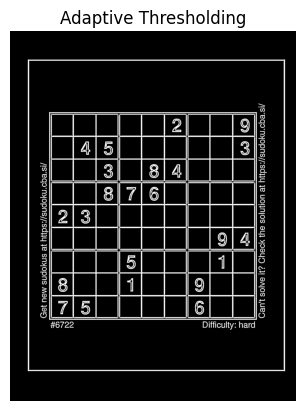

In [26]:
image_path = "report/images/original_2.png"

# Read the image in grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
display_image_grayscale(img, "Original Image")
if img is None:
    raise ValueError("Image not found. Check the path.")

original = img.copy()
print(img.shape)
# Pre-process: Blur and Adaptive Thresholding
# Gaussian blur reduces high-frequency noise
gaussian_kernel = create_gaussian_kernel(9, 1.6)
blurred = linear_filter(img, gaussian_kernel, is_clipped=True)

(hist, bin) = create_histogram(blurred, 256, is_normalized=False)
threshold_val = find_otsu_threshold(hist)
thresh_otsu = perform_global_threshold(blurred, threshold_val, is_inverse=True)
display_image_grayscale(thresh_otsu, f"Otsu Thresholding (threshold value: {threshold_val})")

# Thresholding
thresh_adaptive = apply_adaptive_threshold(blurred, 11, 2, is_inverse=True)
display_image_grayscale(thresh_adaptive, f"Adaptive Thresholding")

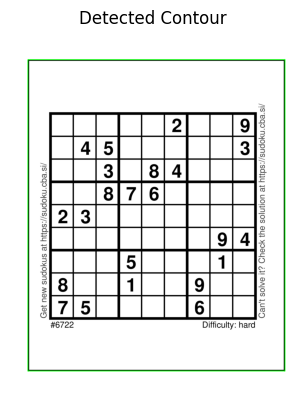

In [27]:
# Find contours (I don't think we can build custom version)
contours, _ = cv2.findContours(thresh_adaptive, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # Suzuki Abe algorithm

contours = sorted(contours, key=cv2.contourArea, reverse=True)


debug_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Example colors (BGR)
colors = [(0, 255, 0), (0, 0, 255), (255, 0, 0)]  

for i, cnt in enumerate([contours[0]]):
    color = colors[i % len(colors)]  # cycle colors if you have more contours
    cv2.drawContours(debug_img, [cnt], -1, color, 3)
display_image_grayscale(debug_img, "Detected Contour")
success = cv2.imwrite("report/images/contour_fail.png", debug_img)

### Another image (Board contour is disconnected)

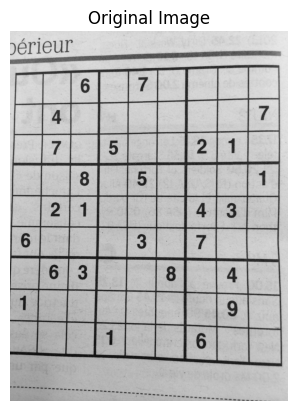

(1280, 960)


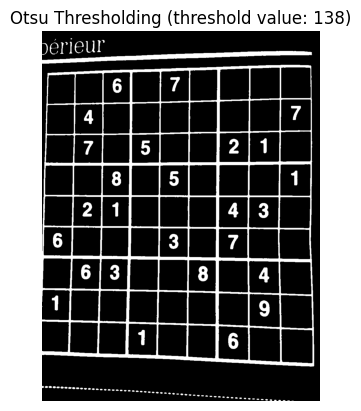

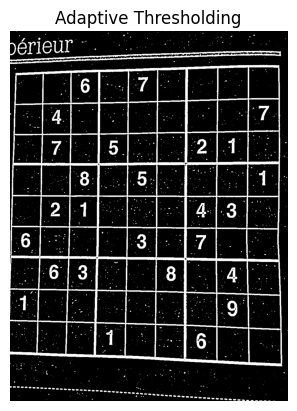

In [28]:
image_path = "report/images/original_3.jpg"

# Read the image in grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
display_image_grayscale(img, "Original Image")
if img is None:
    raise ValueError("Image not found. Check the path.")

original = img.copy()
print(img.shape)
# Pre-process: Blur and Adaptive Thresholding
# Gaussian blur reduces high-frequency noise
gaussian_kernel = create_gaussian_kernel(9, 1.6)
blurred = linear_filter(img, gaussian_kernel, is_clipped=True)

(hist, bin) = create_histogram(blurred, 256, is_normalized=False)
threshold_val = find_otsu_threshold(hist)
thresh_otsu = perform_global_threshold(blurred, threshold_val, is_inverse=True)
display_image_grayscale(thresh_otsu, f"Otsu Thresholding (threshold value: {threshold_val})")

# Thresholding
thresh_adaptive = apply_adaptive_threshold(blurred, 11, 2, is_inverse=True)
display_image_grayscale(thresh_adaptive, f"Adaptive Thresholding")

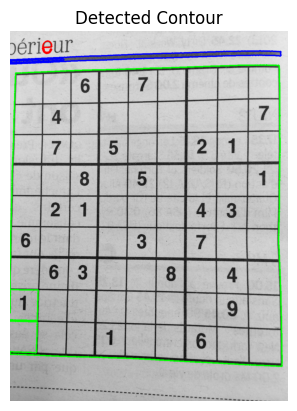

In [29]:
# Find contours (I don't think we can build custom version)
contours, _ = cv2.findContours(thresh_adaptive, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # Suzuki Abe algorithm

contours = sorted(contours, key=cv2.contourArea, reverse=True)


debug_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Example colors (BGR)
colors = [(0, 255, 0), (0, 0, 255), (255, 0, 0)]  

for i, cnt in enumerate([contours[0], contours[1], contours[2]]):
    color = colors[i % len(colors)]  # cycle colors if you have more contours
    cv2.drawContours(debug_img, [cnt], -1, color, 3)
display_image_grayscale(debug_img, "Detected Contour")
success = cv2.imwrite("report/images/contour_fail_2.png", debug_img)